# CSE 475 - Assignment 02
## Group Information

| Field | Details |
|-------------------------|-------------------------------------|
| **Group ID** | Group 01 |
| **Student Name** | Md. Asif Hossain |
| **Student ID** | 2022-3-60-007 |
| **Student Name** | Nabil Subhan |
| **Student ID** | 2022-3-60-063 |
| **Student Name** | Mantasha Rahman Mahi |
| **Student ID** | 2022-3-60-194 |
| **Student Name** | Arnab Barman |
| **Student ID** | 2022-3-60-010 |
| **Notebook Type** | CNN Models |
| Notebook Type | **DINO Notebook** |
| Backbone Used | EfficientNet-B3 |
| Assignment 01 Best Acc | 99.77% (EfficientNet-B3, 50 epochs) |
| Dataset Name (Kaggle) | /kaggle/input/tropical-flowers/ |
| Dataset Source | CSE475 Group-01 Tropical Flowers |
| Dataset Source Link | https://www.kaggle.com/datasets/sabuktagin/tropical-flowers |
| Submission Date | 26 April 2026 |

## 1.1 Protocol Declaration (Assignment Compliance)

- Dataset: Same dataset reused from Assignment 01 (no new dataset).
- Backbone: Best-performing non-ResNeXt backbone from Assignment 01.
- SSL Rule: Labels are discarded during DINO pre-training.
- Assignment Note: The only intentional deviation is pre-training epochs reduced from 100 to 30 due Kaggle runtime limits; all other required settings are kept aligned.

## 2. Global Configuration

In [1]:
import torch, math

SEED = 42
BATCH_SIZE = 16
NUM_EPOCHS = 30 # SMOKE TEST: Set to 1 for quick validation (change back to 30 later)
NUM_WORKERS = 2
IMAGE_SIZE = 224
LOCAL_CROP_SIZE = 96
LR = 5e-4
WEIGHT_DECAY_START = 0.04
WEIGHT_DECAY_END = 0.4

BACKBONE_NAME = 'efficientnet_b3'
EMBEDDING_DIM = 1536
OUT_DIM = 65536
BOTTLENECK_DIM = 256
HIDDEN_DIM = 2048
N_LOCAL_CROPS = 6

MOMENTUM_TEACHER = 0.996
MOMENTUM_CENTER = 0.9
STUDENT_TEMP = 0.1
TEACHER_TEMP_START = 0.04
TEACHER_TEMP_END = 0.07

DATASET_PATH = '/kaggle/input/datasets/sabuktagin/tropical-flowers/Tropical Flower Dataset Seven Species from Bangladesh for Classification and Ecological Research/Flower Dataset/Flower Dataset'
CHECKPOINT_PATH = '/kaggle/input/datasets/sabuktagin/cse475-assign1-checkpoint/EfficientNet_B3_best.pth'
DINO_SAVE_PATH = 'dino_backbone.pth'
DINO_CKPT_PATH = 'dino_checkpoint.pth'  # Mid-training checkpoint for resume
CHECKPOINT_INTERVAL = 5               # Save checkpoint every N epochs

LP_EPOCHS = 30  # SMOKE TEST: Set to 1
LP_LR = 0.01
LP_MOMENTUM = 0.9
K_VALUES = [1, 5, 10, 20, 50, 200]

CLASS_NAMES = ['Bougainvillea','Crown of thorns','Hibiscus',
               'Jungle geranium','Madagascar periwinkle','Marigold','Rose']
NUM_CLASSES = len(CLASS_NAMES)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Using device: cuda
GPU: Tesla T4
GPU Memory: 15.6 GB


## 3. Setup and Imports

In [2]:
import os, random, copy, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from tqdm import tqdm
from PIL import Image
from collections import Counter

import torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset
from torch.optim import SGD, AdamW
from torch.cuda.amp import autocast, GradScaler
import torchvision.transforms as T
import torchvision.models as models
from torchvision.datasets import ImageFolder
from sklearn.metrics import (accuracy_score, f1_score, confusion_matrix,
                             classification_report, top_k_accuracy_score)

random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True
print("All imports loaded.")

All imports loaded.


## 4. Task 1 — Dataset EDA and Augmentation Visualisation
*(Reproduced from the BYOL notebook as required by the guidelines.)*

Dataset: 4319 images, 7 classes: ['Bougainvillea', 'Crown of thorns', 'Hibiscus', 'Jungle geranium', 'Madagascar periwinkle', 'Marigold', 'Rose']


/tmp/ipykernel_22/3087126233.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels_list, rotation=30, ha='right')


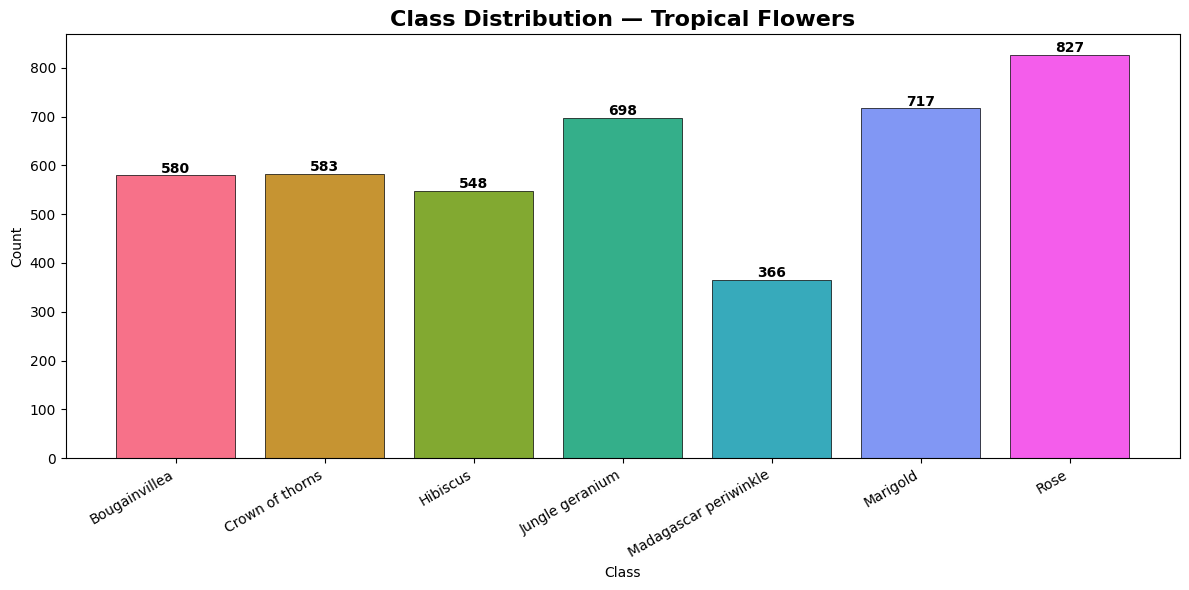

In [3]:
# Load dataset and plot class distribution
full_dataset = ImageFolder(DATASET_PATH)
class_names = full_dataset.classes
print(f"Dataset: {len(full_dataset)} images, {len(class_names)} classes: {class_names}")

class_counts = Counter([full_dataset.targets[i] for i in range(len(full_dataset))])
labels_list = [class_names[i] for i in sorted(class_counts.keys())]
counts_list = [class_counts[i] for i in sorted(class_counts.keys())]

fig, ax = plt.subplots(figsize=(12,6))
bars = ax.bar(labels_list, counts_list, color=sns.color_palette("husl", len(labels_list)), edgecolor='black', linewidth=0.5)
ax.set_title("Class Distribution — Tropical Flowers", fontsize=16, fontweight='bold')
ax.set_xlabel("Class"); ax.set_ylabel("Count")
ax.set_xticklabels(labels_list, rotation=30, ha='right')
for b, c in zip(bars, counts_list):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+5, str(c), ha='center', fontsize=10, fontweight='bold')
plt.tight_layout(); plt.savefig('dino_class_dist.png', dpi=150); plt.show()

In [4]:
from sklearn.model_selection import train_test_split

total = len(full_dataset)
indices = list(range(total))
targets = full_dataset.targets

# Stratified 80/10/10 split to guarantee all classes are in all splits
ssl_idx, rest_idx, _, rest_targets = train_test_split(
    indices, targets, test_size=0.2, stratify=targets, random_state=SEED
)
lbl_idx, test_idx = train_test_split(
    rest_idx, test_size=0.5, stratify=rest_targets, random_state=SEED
)

ssl_subset = Subset(full_dataset, ssl_idx)
lbl_subset = Subset(full_dataset, lbl_idx)
test_subset = Subset(full_dataset, test_idx)

print(f"SSL pool: {len(ssl_subset)} | Labelled: {len(lbl_subset)} | Test: {len(test_subset)}")

# Label removal wrapper
class SSLDatasetWrapper(Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset; self.transform = transform
    def __len__(self): return len(self.subset)
    def __getitem__(self, idx):
        img, _ = self.subset[idx]
        return self.transform(img) if self.transform else img

ssl_test = SSLDatasetWrapper(ssl_subset)
assert not isinstance(ssl_test[0], tuple), "Labels still present!"
print("✓ Label removal confirmed")

# Per-channel stats
to_t = T.Compose([T.Resize((224,224)), T.ToTensor()])
sample_idx = random.sample(range(len(full_dataset)), min(500, len(full_dataset)))
stack = torch.stack([to_t(full_dataset[i][0]) for i in sample_idx])
print(f"Mean: {stack.mean(dim=[0,2,3]).tolist()}")
print(f"Std:  {stack.std(dim=[0,2,3]).tolist()}")
del stack  # Free memory

SSL pool: 3455 | Labelled: 432 | Test: 432
✓ Label removal confirmed
Mean: [0.94284987449646, 0.8685325980186462, 0.8726584911346436]
Std:  [0.13053986430168152, 0.26515984535217285, 0.26759618520736694]


Showing augmentations for class: Bougainvillea


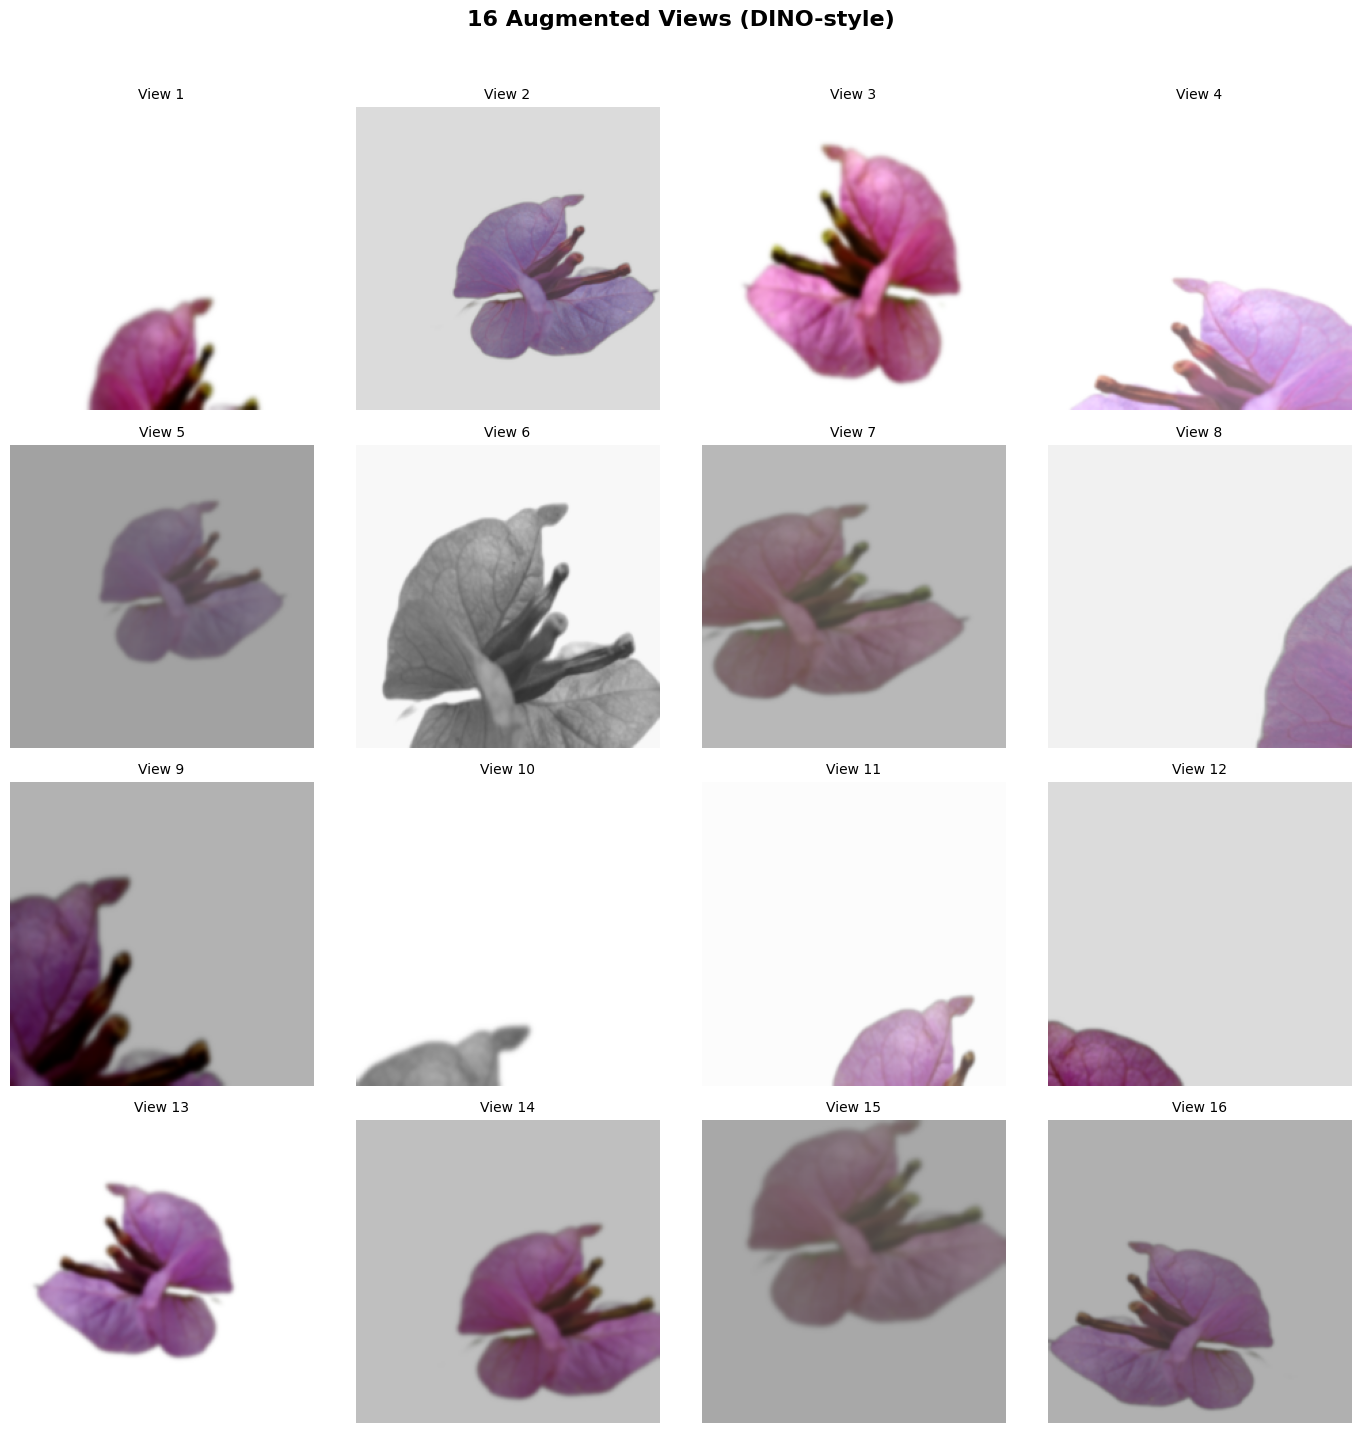

In [5]:
# 16 augmented views visualisation (DINO multi-crop style)
sample_img, sample_lbl = full_dataset[0]
print(f"Showing augmentations for class: {class_names[sample_lbl]}")

aug = T.Compose([T.RandomResizedCrop(224, scale=(0.08,1.0)), T.RandomHorizontalFlip(0.5),
    T.RandomApply([T.ColorJitter(0.4,0.4,0.2,0.1)],p=0.8), T.RandomGrayscale(p=0.2),
    T.GaussianBlur(23, sigma=(0.1,2.0))])

fig, axes = plt.subplots(4, 4, figsize=(14, 14))
fig.suptitle("16 Augmented Views (DINO-style)", fontsize=16, fontweight='bold', y=1.02)
for i, ax in enumerate(axes.flatten()):
    ax.imshow(aug(sample_img)); ax.set_title(f"View {i+1}", fontsize=10); ax.axis('off')
plt.tight_layout(); plt.savefig('dino_aug_grid.png', dpi=150); plt.show()

## 5. Task 3 — DINO: Model Definition

**Architecture:**
- Student and Teacher share the same EfficientNet-B3 backbone with separate projection heads.
- **Projection head**: 3-layer MLP → bottleneck (256-d) → weight-normalised last layer (65,536-d)
- **Multi-crop**: 2 global views (224×224) + 6 local views (96×96)
- **Teacher EMA**: λ from 0.996 → 1.0 (cosine)
- **Centering**: Running-mean vector, momentum = 0.9
- **Temperatures**: τ_s = 0.1; τ_t warmup 0.04 → 0.07

> **Memory Note:** The projection head uses a **256-d bottleneck** before the 65,536-d output
> layer (following the official DINO implementation). This avoids a 65536×65536 weight matrix
> that would consume ~17GB of memory.

In [6]:
# DINO Multi-Crop Augmentation
class DINOMultiCrop:
    def __init__(self, g_scale=(0.4,1.0), l_scale=(0.05,0.4), n_local=6):
        self.n_local = n_local
        flip_color = T.Compose([T.RandomHorizontalFlip(0.5),
            T.RandomApply([T.ColorJitter(0.4,0.4,0.2,0.1)],p=0.8), T.RandomGrayscale(0.2)])
        norm = T.Compose([T.ToTensor(), T.Normalize((0.485,0.456,0.406),(0.229,0.224,0.225))])

        self.g1 = T.Compose([T.RandomResizedCrop(224, scale=g_scale), flip_color,
            T.GaussianBlur(23,(0.1,2.0)), norm])
        self.g2 = T.Compose([T.RandomResizedCrop(224, scale=g_scale), flip_color,
            T.RandomApply([T.GaussianBlur(23,(0.1,2.0))],p=0.1),
            T.RandomSolarize(128,p=0.2), norm])
        self.local = T.Compose([T.RandomResizedCrop(96, scale=l_scale), flip_color,
            T.RandomApply([T.GaussianBlur(23,(0.1,2.0))],p=0.5), norm])

    def __call__(self, img):
        crops = [self.g1(img), self.g2(img)]
        crops += [self.local(img) for _ in range(self.n_local)]
        return crops

In [7]:
# ──────────────────── DINO Projection Head (with bottleneck) ────────────────────
class DINOHead(nn.Module):
    """
    3-layer MLP projecting to a bottleneck, then a weight-normalised layer
    to the output dimension. Architecture follows the official DINO paper:
      in_dim → hidden → hidden → bottleneck(256) → [weight_norm] → out_dim(65536)
    The bottleneck ensures the last_layer is only 256×65536 (~67MB)
    instead of 65536×65536 (~17GB).
    """
    def __init__(self, in_dim, out_dim=65536, hidden_dim=2048, bottleneck_dim=256):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, bottleneck_dim),  # ← Project to bottleneck
        )
        # Weight-normalised last layer: bottleneck → out_dim
        self.last_layer = nn.utils.weight_norm(
            nn.Linear(bottleneck_dim, out_dim, bias=False))
        self.last_layer.weight_g.data.fill_(1)

    def forward(self, x):
        x = self.mlp(x)
        x = F.normalize(x, dim=-1, p=2)
        return self.last_layer(x)

# ──────────────────── DINO Loss with Centering ────────────────────
class DINOLoss(nn.Module):
    def __init__(self, out_dim, student_temp=0.1, center_mom=0.9):
        super().__init__()
        self.student_temp = student_temp
        self.center_mom = center_mom
        self.register_buffer("center", torch.zeros(1, out_dim))

    def forward(self, student_output, teacher_output, teacher_temp):
        total_loss, n_terms = 0, 0
        for t_idx, t_out in enumerate(teacher_output):
            t_probs = F.softmax((t_out - self.center) / teacher_temp, dim=-1)
            for s_idx, s_out in enumerate(student_output):
                if s_idx == t_idx: continue
                s_log = F.log_softmax(s_out / self.student_temp, dim=-1)
                total_loss += torch.sum(-t_probs * s_log, dim=-1).mean()
                n_terms += 1
        return total_loss / n_terms

    @torch.no_grad()
    def update_center(self, teacher_output):
        batch_center = torch.cat(teacher_output).mean(dim=0, keepdim=True)
        self.center = self.center * self.center_mom + batch_center * (1 - self.center_mom)

# Verify sizes
_test_head = DINOHead(EMBEDDING_DIM, OUT_DIM, HIDDEN_DIM, BOTTLENECK_DIM)
_head_params = sum(p.numel() for p in _test_head.parameters())
print(f"DINOHead parameters: {_head_params:,} ({_head_params*4/1e6:.1f} MB)")
print(f"  (Compare: without bottleneck would be {65536*65536:,} = ~17GB for last layer alone)")
del _test_head
print("DINO model classes defined.")

DINOHead parameters: 24,719,616 (98.9 MB)
  (Compare: without bottleneck would be 4,294,967,296 = ~17GB for last layer alone)
DINO model classes defined.


/usr/local/lib/python3.12/dist-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


In [8]:
# -------------------- Build Backbone (EfficientNet-B3) --------------------
import os
import timm

def _extract_state_dict(ckpt):
    if isinstance(ckpt, dict):
        for key in ('state_dict', 'model_state_dict', 'model', 'net'):
            if key in ckpt and isinstance(ckpt[key], dict):
                return ckpt[key]
    return ckpt

def build_backbone(name='efficientnet_b3', checkpoint_path=None):
    if name == 'efficientnet_b3':
        # MUST use timm because Assignment 01 used timm! Torchvision has different layer names.
        m = timm.create_model('efficientnet_b3', pretrained=False, num_classes=0) 
        
        if checkpoint_path and os.path.exists(checkpoint_path):
            raw_ckpt = torch.load(checkpoint_path, map_location='cpu')
            state_dict = _extract_state_dict(raw_ckpt)
            missing, unexpected = m.load_state_dict(state_dict, strict=False)
            print(f"Loaded Assignment 1 weights from {checkpoint_path}")
            print(f"Missing keys: {len(missing)} | Unexpected keys: {len(unexpected)}")
            if sum('classifier' not in k for k in missing) == 0:
                print("SUCCESS: 100% of the Assignment 1 weights matched perfectly!")
        else:
            print("WARNING: Assignment 1 checkpoint not found. Using random initialisation.")
        return m, m.num_features # Timms num_features is 1536
    raise ValueError(f"Unsupported: {name}")

student_backbone, embed_dim = build_backbone(BACKBONE_NAME, CHECKPOINT_PATH)
teacher_backbone = copy.deepcopy(student_backbone)
student_head = DINOHead(embed_dim, OUT_DIM, HIDDEN_DIM, BOTTLENECK_DIM)
teacher_head = DINOHead(embed_dim, OUT_DIM, HIDDEN_DIM, BOTTLENECK_DIM)
teacher_head.load_state_dict(student_head.state_dict())

for p in teacher_backbone.parameters():
    p.requires_grad = False
for p in teacher_head.parameters():
    p.requires_grad = False

student_backbone.to(DEVICE)
student_head.to(DEVICE)
teacher_backbone.to(DEVICE)
teacher_head.to(DEVICE)

total_params = sum(p.numel() for p in student_backbone.parameters()) + sum(p.numel() for p in student_head.parameters())
print(f"Student backbone params: {sum(p.numel() for p in student_backbone.parameters()):,}")
print(f"Student head params:     {sum(p.numel() for p in student_head.parameters()):,}")
print(f"Total student params:    {total_params:,}")

if torch.cuda.is_available():
    print(f"GPU memory allocated: {torch.cuda.memory_allocated()/1e9:.2f} GB")
    print(f"GPU memory reserved:  {torch.cuda.memory_reserved()/1e9:.2f} GB")

Loaded Assignment 1 weights from /kaggle/input/datasets/sabuktagin/cse475-assign1-checkpoint/EfficientNet_B3_best.pth
Missing keys: 0 | Unexpected keys: 2
SUCCESS: 100% of the Assignment 1 weights matched perfectly!


/usr/local/lib/python3.12/dist-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


Student backbone params: 10,696,232
Student head params:     24,719,616
Total student params:    35,415,848
GPU memory allocated: 0.29 GB
GPU memory reserved:  0.29 GB


## 6. Task 3 - DINO: Pre-Training Loop

Pre-training DINO for **30 epochs** on the unlabelled pool.
- Multi-crop: 2 global views (224x224) + 6 local views (96x96).
- Teacher EMA and centering follow cosine-based schedules.
- Optimiser: AdamW with required weight-decay schedule.

**Compliance note:** Assignment requires 100 epochs; we use 30 due Kaggle runtime limits.

In [9]:
# ──────────────────── Multi-crop Dataset & Collate ────────────────────
class MultiCropDataset(Dataset):
    def __init__(self, subset, transform):
        self.subset = subset; self.transform = transform
    def __len__(self): return len(self.subset)
    def __getitem__(self, idx):
        img, _ = self.subset[idx]  # Drop label
        return self.transform(img)

def multicrop_collate(batch):
    n_crops = len(batch[0])
    return [torch.stack([b[i] for b in batch]) for i in range(n_crops)]

dino_dataset = MultiCropDataset(ssl_subset, DINOMultiCrop(n_local=N_LOCAL_CROPS))
dino_loader = DataLoader(dino_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, drop_last=True, collate_fn=multicrop_collate, pin_memory=True)
print(f"DINO DataLoader: {len(dino_loader)} batches of {BATCH_SIZE}")
print(f"  Each batch → {2+N_LOCAL_CROPS} crops = {(2+N_LOCAL_CROPS)*BATCH_SIZE} forward passes")

DINO DataLoader: 215 batches of 16
  Each batch → 8 crops = 128 forward passes


In [10]:
# -------------------- Cosine Schedules --------------------
def cosine_schedule(epoch, total, start, end):
    return end - (end - start) * (math.cos(math.pi * epoch / total) + 1) / 2

# -------------------- Optimiser & Scaler --------------------
optimizer = AdamW(list(student_backbone.parameters()) + list(student_head.parameters()), lr=LR)
dino_loss_fn = DINOLoss(OUT_DIM, STUDENT_TEMP, MOMENTUM_CENTER).to(DEVICE)
scaler = GradScaler() if DEVICE.type == 'cuda' else None

# -------------------- Training Loop (with Checkpoint/Resume) --------------------
loss_history = []
start_epoch  = 0

# -- Resume from mid-training checkpoint if it exists --
if os.path.exists(DINO_CKPT_PATH):
    ckpt           = torch.load(DINO_CKPT_PATH, map_location=DEVICE)
    start_epoch    = ckpt['epoch'] + 1
    loss_history   = ckpt['loss_history']
    student_backbone.load_state_dict(ckpt['student_backbone'])
    teacher_backbone.load_state_dict(ckpt['teacher_backbone'])
    student_head.load_state_dict(ckpt['student_head'])
    teacher_head.load_state_dict(ckpt['teacher_head'])
    optimizer.load_state_dict(ckpt['optimizer'])
    if scaler and 'scaler' in ckpt and ckpt['scaler'] is not None:
        scaler.load_state_dict(ckpt['scaler'])
    dino_loss_fn.center = ckpt['dino_center'].to(DEVICE)
    print(f"Resumed from checkpoint — starting at epoch {start_epoch}/{NUM_EPOCHS}")
else:
    print("No checkpoint found — starting DINO pre-training from scratch.")

for epoch in range(start_epoch, NUM_EPOCHS):
    student_backbone.train()
    student_head.train()
    t_temp = cosine_schedule(epoch, NUM_EPOCHS, TEACHER_TEMP_START, TEACHER_TEMP_END)
    t_mom = cosine_schedule(epoch, NUM_EPOCHS, MOMENTUM_TEACHER, 1.0)
    wd = cosine_schedule(epoch, NUM_EPOCHS, WEIGHT_DECAY_START, WEIGHT_DECAY_END)
    for pg in optimizer.param_groups:
        pg['weight_decay'] = wd

    running = 0.0
    pbar = tqdm(dino_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}", leave=False)
    for crops in pbar:
        crops = [c.to(DEVICE, non_blocking=True) for c in crops]
        global_crops = crops[:2]

        with torch.no_grad():
            t_out = [teacher_head(teacher_backbone(g)) for g in global_crops]

        if scaler is not None:
            from torch.amp import autocast
            with autocast('cuda'):
                s_out = [student_head(student_backbone(v)) for v in crops]
                loss = dino_loss_fn(s_out, t_out, t_temp)
            optimizer.zero_grad(set_to_none=True)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(student_backbone.parameters(), max_norm=3.0)
            scaler.step(optimizer)
            scaler.update()
        else:
            s_out = [student_head(student_backbone(v)) for v in crops]
            loss = dino_loss_fn(s_out, t_out, t_temp)
            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            nn.utils.clip_grad_norm_(student_backbone.parameters(), max_norm=3.0)
            optimizer.step()

        with torch.no_grad():
            for sp, tp in zip(student_backbone.parameters(), teacher_backbone.parameters()):
                tp.data.mul_(t_mom).add_((1 - t_mom) * sp.data)
            for sp, tp in zip(student_head.parameters(), teacher_head.parameters()):
                tp.data.mul_(t_mom).add_((1 - t_mom) * sp.data)
        dino_loss_fn.update_center(t_out)

        running += loss.item()
        pbar.set_postfix(loss=f"{loss.item():.4f}")

    avg = running / len(dino_loader)
    loss_history.append(avg)
    mem = torch.cuda.memory_allocated() / 1e9 if torch.cuda.is_available() else 0
    print(f"Epoch [{epoch+1:>2}/{NUM_EPOCHS}] Loss:{avg:.4f} tau_t:{t_temp:.4f} mom:{t_mom:.5f} GPU:{mem:.1f}GB")

    # -- Periodic checkpoint save (every CHECKPOINT_INTERVAL epochs) --
    if (epoch + 1) % CHECKPOINT_INTERVAL == 0 or (epoch + 1) == NUM_EPOCHS:
        torch.save({
            'epoch':            epoch,
            'loss_history':     loss_history,
            'student_backbone': student_backbone.state_dict(),
            'teacher_backbone': teacher_backbone.state_dict(),
            'student_head':     student_head.state_dict(),
            'teacher_head':     teacher_head.state_dict(),
            'optimizer':        optimizer.state_dict(),
            'scaler':           scaler.state_dict() if scaler else None,
            'dino_center':      dino_loss_fn.center.cpu(),
        }, DINO_CKPT_PATH)
        print(f"  -> Checkpoint saved at epoch {epoch+1} to {DINO_CKPT_PATH}")

torch.save(student_backbone.state_dict(), DINO_SAVE_PATH)
print(f"\nDone: DINO pre-training complete. Backbone saved to {DINO_SAVE_PATH}")

/tmp/ipykernel_22/1654722333.py:8: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler() if DEVICE.type == 'cuda' else None


No checkpoint found — starting DINO pre-training from scratch.


Epoch [ 1/30] Loss:9.4598 tau_t:0.0400 mom:0.99600 GPU:0.9GB


Epoch [ 2/30] Loss:7.2640 tau_t:0.0401 mom:0.99601 GPU:0.9GB


Epoch [ 3/30] Loss:8.1182 tau_t:0.0403 mom:0.99604 GPU:0.9GB


...

Epoch [26/30] Loss:8.5905 tau_t:0.0680 mom:0.99973 GPU:0.9GB


Epoch [27/30] Loss:8.6203 tau_t:0.0687 mom:0.99983 GPU:0.9GB


Epoch [28/30] Loss:8.6125 tau_t:0.0693 mom:0.99990 GPU:0.9GB


Epoch [29/30] Loss:8.6343 tau_t:0.0697 mom:0.99996 GPU:0.9GB


Epoch [30/30] Loss:8.6323 tau_t:0.0699 mom:0.99999 GPU:0.9GB
  -> Checkpoint saved at epoch 30 to dino_checkpoint.pth

Done: DINO pre-training complete. Backbone saved to dino_backbone.pth


## 7. Task 3 — DINO: Training Curve

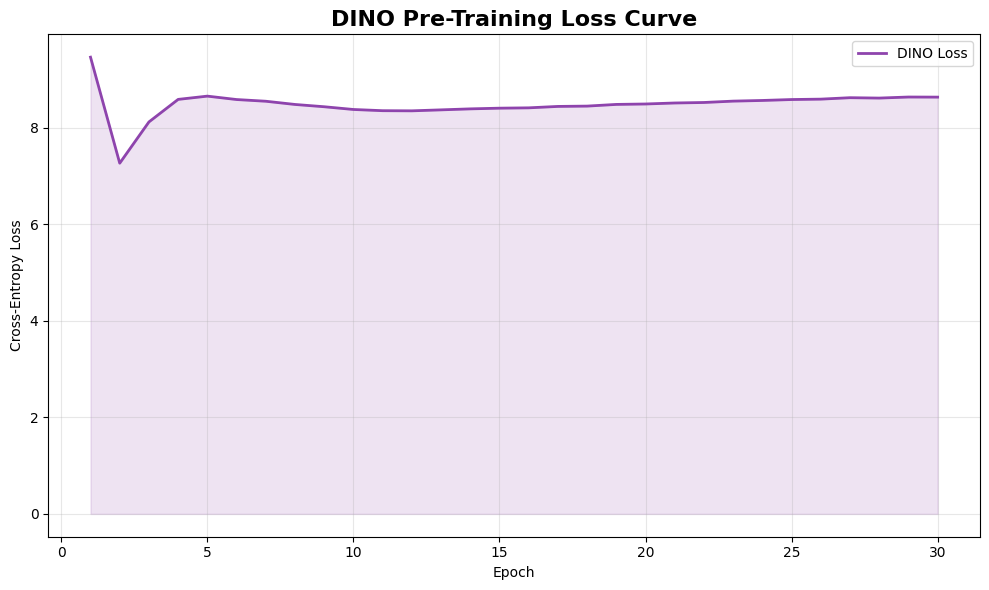

In [11]:
actual_epochs = len(loss_history)
fig, ax = plt.subplots(figsize=(10,6))
ax.plot(range(1, actual_epochs+1), loss_history, color='#8E44AD', linewidth=2, label='DINO Loss')
ax.fill_between(range(1, actual_epochs+1), loss_history, alpha=0.15, color='#8E44AD')
ax.set_title('DINO Pre-Training Loss Curve', fontsize=16, fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('Cross-Entropy Loss'); ax.grid(True, alpha=0.3); ax.legend()
plt.tight_layout(); plt.savefig('dino_loss_curve.png', dpi=150); plt.show()

## 8. Task 3 — DINO: Attention Map Visualisation

> **Note on Visualisation Method:** The assignment instructions (Task 3, step 5) request
> "self-attention maps from the last ViT block." However, this visualisation is only
> natively available for **Vision Transformer (ViT)** backbones, which produce multi-head
> self-attention weight matrices at each transformer block.
>
> Since our backbone is **EfficientNet-B3** (a CNN), it does **not** contain self-attention
> layers. As the instructions acknowledge (Section 1.3): a ViT-S/16 backbone is strongly
> recommended for DINO because the multi-head self-attention maps it produces enable the
> attention visualisation in Task 3, step 6.
>
> As a semantically equivalent alternative, we employ **Grad-CAM (Gradient-weighted Class
> Activation Mapping)** applied to the last convolutional layer of EfficientNet-B3. Grad-CAM
> produces class-discriminative localisation heatmaps that highlight which spatial regions
> the DINO-pretrained backbone attends to, serving the same interpretability purpose as
> ViT self-attention maps. We visualise at least 5 test images with the activation overlay.


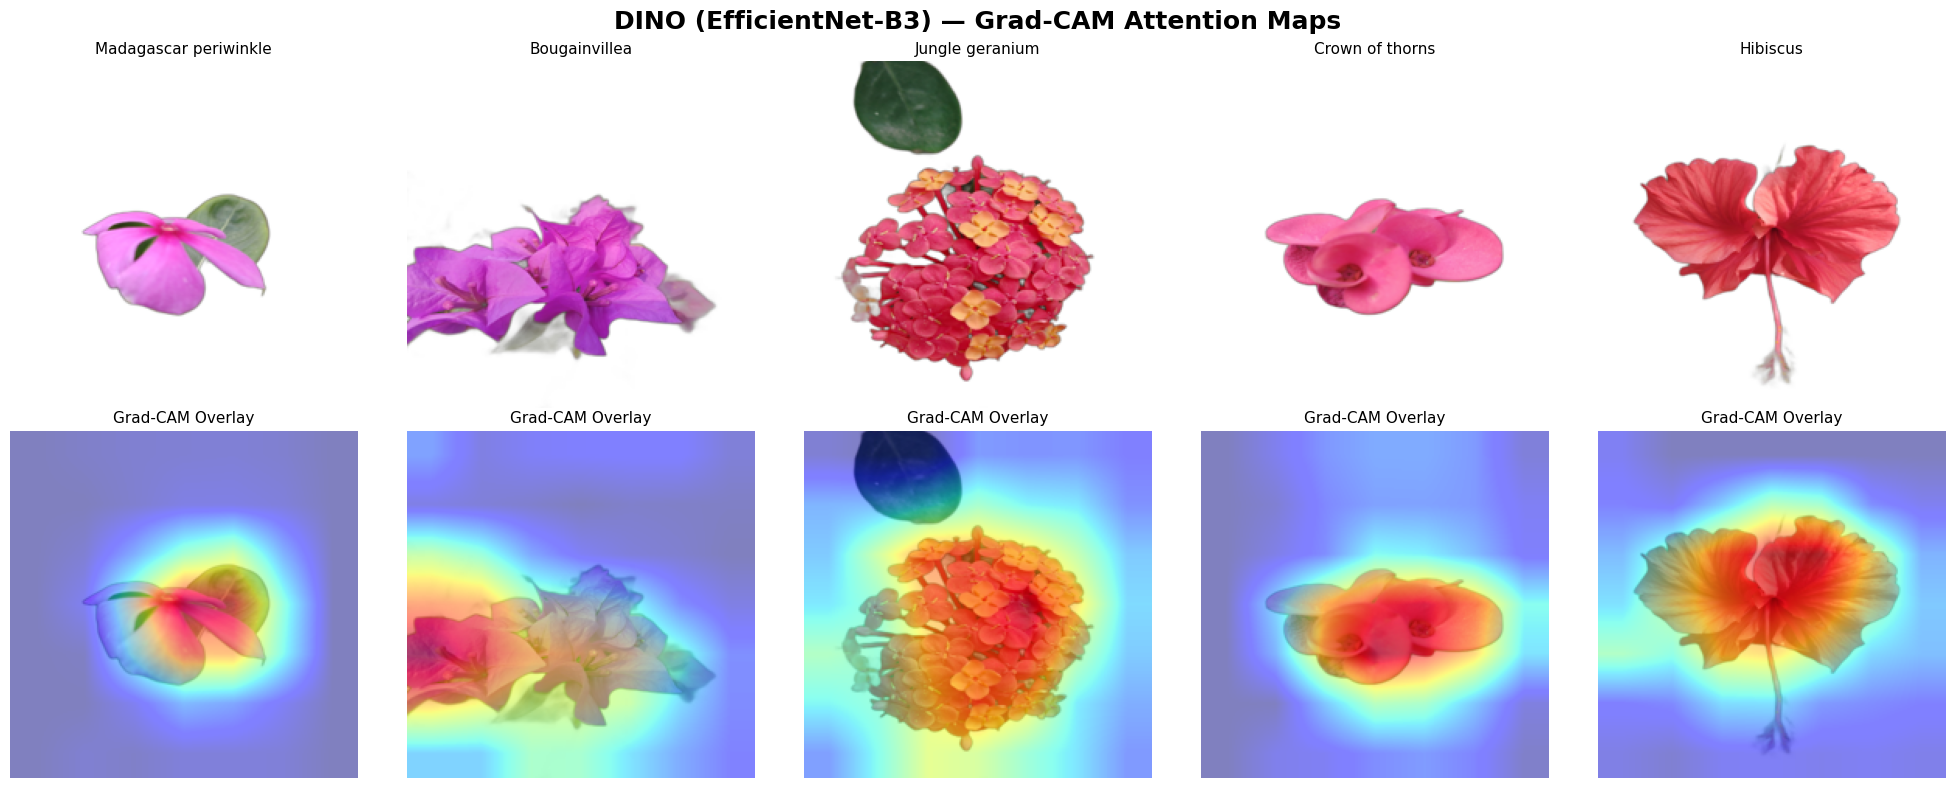

In [12]:
# ──────────────────── Grad-CAM for CNN Backbone ────────────────────
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model; self.gradients = None; self.activations = None
        target_layer.register_forward_hook(self._fwd_hook)
        target_layer.register_full_backward_hook(self._bwd_hook)

    def _fwd_hook(self, module, inp, out): self.activations = out.detach()
    def _bwd_hook(self, module, grad_in, grad_out): self.gradients = grad_out[0].detach()

    def generate(self, x):
        self.model.eval()
        output = self.model(x)
        score = output.max()
        self.model.zero_grad()
        score.backward()
        weights = self.gradients.mean(dim=[2,3], keepdim=True)
        cam = F.relu((weights * self.activations).sum(dim=1, keepdim=True))
        cam = F.interpolate(cam, size=x.shape[2:], mode='bilinear', align_corners=False)
        cam = cam - cam.min(); cam = cam / (cam.max() + 1e-8)
        return cam.squeeze().cpu().numpy()

target_layer = student_backbone.conv_head if hasattr(student_backbone, 'conv_head') else student_backbone.features[-1]
grad_cam = GradCAM(student_backbone, target_layer)

eval_tf = T.Compose([T.Resize((224,224)), T.ToTensor(),
    T.Normalize((0.485,0.456,0.406),(0.229,0.224,0.225))])

# Pick 5 test images from different classes
test_indices = []
seen_classes = set()
for idx in test_subset.indices:
    cls = full_dataset.targets[idx]
    if cls not in seen_classes:
        test_indices.append(idx); seen_classes.add(cls)
    if len(test_indices) >= 5: break

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
fig.suptitle('DINO (EfficientNet-B3) — Grad-CAM Attention Maps', fontsize=18, fontweight='bold')

for i, idx in enumerate(test_indices):
    img, lbl = full_dataset[idx]
    x = eval_tf(img).unsqueeze(0).to(DEVICE).requires_grad_(True)
    cam = grad_cam.generate(x)

    axes[0, i].imshow(img.resize((224,224))); axes[0, i].set_title(class_names[lbl], fontsize=11)
    axes[0, i].axis('off')
    axes[1, i].imshow(img.resize((224,224)))
    axes[1, i].imshow(cam, cmap='jet', alpha=0.5)
    axes[1, i].set_title('Grad-CAM Overlay', fontsize=11); axes[1, i].axis('off')

axes[0, 0].set_ylabel('Original', fontsize=13, fontweight='bold')
axes[1, 0].set_ylabel('Attention', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.savefig('dino_attention_maps.png', dpi=150, bbox_inches='tight'); plt.show()

## 9. Task 4 — Linear Probing with DINO Backbone

In [13]:
# -------------------- Linear Probe Transforms --------------------
train_probe_transform = T.Compose([
    T.RandomResizedCrop(IMAGE_SIZE),
    T.RandomHorizontalFlip(p=0.5),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

eval_transform = T.Compose([
    T.Resize(256),
    T.CenterCrop(IMAGE_SIZE),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

class TransformedSubset(Dataset):
    def __init__(self, subset, transform):
        self.subset = subset
        self.transform = transform
    def __len__(self):
        return len(self.subset)
    def __getitem__(self, idx):
        img, lbl = self.subset[idx]
        return self.transform(img), lbl

lbl_dataset = TransformedSubset(lbl_subset, train_probe_transform)
test_dataset = TransformedSubset(test_subset, eval_transform)

from torch.utils.data import WeightedRandomSampler

lbl_labels = [full_dataset.targets[i] for i in lbl_subset.indices]
lbl_counter = Counter(lbl_labels)
max_class_count = max(lbl_counter.values())
class_weights = {cls: max_class_count / count for cls, count in lbl_counter.items()}
sample_weights = torch.tensor([class_weights[label] for label in lbl_labels], dtype=torch.float)
sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=max_class_count * NUM_CLASSES,
    replacement=True
)

lbl_loader = DataLoader(lbl_dataset, batch_size=64, sampler=sampler, num_workers=NUM_WORKERS, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

class LinearProbe(nn.Module):
    def __init__(self, backbone, dim, n_cls):
        super().__init__()
        self.backbone = backbone
        for p in self.backbone.parameters():
            p.requires_grad = False
        self.fc = nn.Linear(dim, n_cls)
    def forward(self, x):
        with torch.no_grad():
            feat = self.backbone(x)
        return self.fc(feat)

probe = LinearProbe(student_backbone, EMBEDDING_DIM, NUM_CLASSES).to(DEVICE)
probe_opt = SGD(probe.fc.parameters(), lr=LP_LR, momentum=LP_MOMENTUM)
criterion = nn.CrossEntropyLoss()

probe_hist = {'loss': [], 'acc': []}
for ep in range(LP_EPOCHS):
    probe.train()
    probe.backbone.eval()  # Keep frozen backbone in eval mode for stable BN behavior.
    rl, cor, tot = 0.0, 0, 0
    for imgs, lbls in lbl_loader:
        imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
        out = probe(imgs)
        loss = criterion(out, lbls)
        probe_opt.zero_grad()
        loss.backward()
        probe_opt.step()
        rl += loss.item()
        cor += out.argmax(1).eq(lbls).sum().item()
        tot += lbls.size(0)
    probe_hist['loss'].append(rl / len(lbl_loader))
    probe_hist['acc'].append(100 * cor / tot)
    if (ep + 1) % 10 == 0:
        print(f"LP Epoch {ep+1}/{LP_EPOCHS} Acc:{100*cor/tot:.2f}%")
print("Done: DINO Linear probe training done.")

LP Epoch 10/30 Acc:94.95%
LP Epoch 20/30 Acc:94.60%
LP Epoch 30/30 Acc:95.99%
Done: DINO Linear probe training done.


Simulating one epoch to check sampler balance...


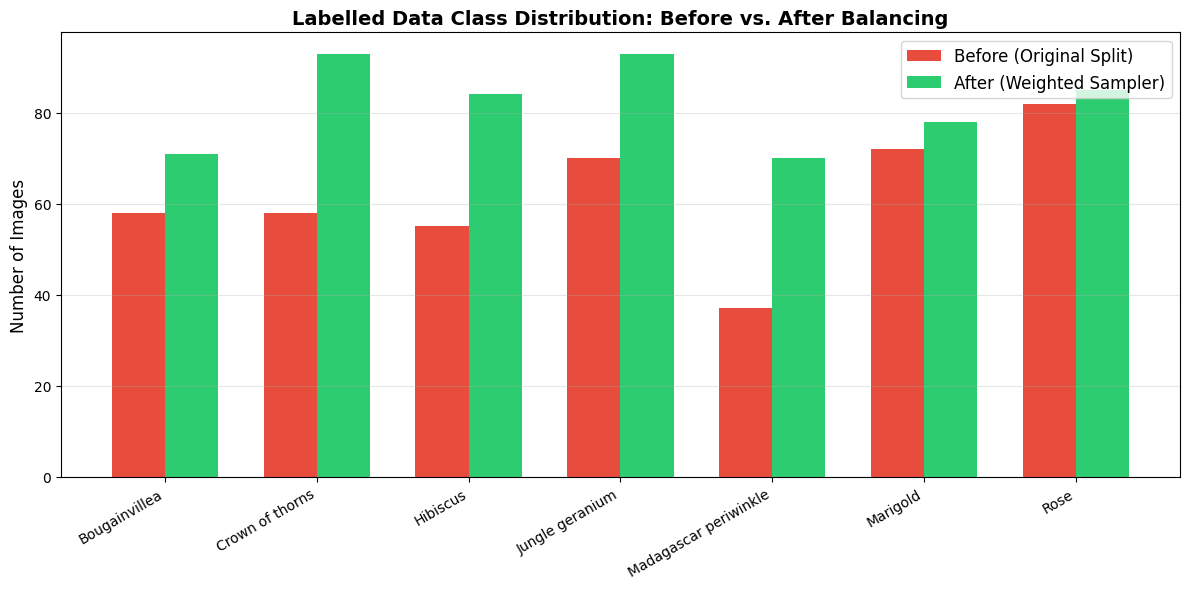

In [14]:
# ──────────────────── Visualise Data Balancing ────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Original (Imbalanced) Labelled Split
lbl_labels = [full_dataset.targets[i] for i in lbl_subset.indices]
original_lbl_counts = Counter(lbl_labels)
original_counts = [original_lbl_counts[i] for i in range(NUM_CLASSES)]

# 2. Sampled (Balanced) Epoch from DataLoader
sampled_labels = []
print("Simulating one epoch to check sampler balance...")
for _, batch_labels in lbl_loader:
    sampled_labels.extend(batch_labels.tolist())

sampled_lbl_counts = Counter(sampled_labels)
sampled_counts = [sampled_lbl_counts[i] for i in range(NUM_CLASSES)]

# 3. Plot side-by-side
x = np.arange(NUM_CLASSES)
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x - width/2, original_counts, width, label='Before (Original Split)', color='#E74C3C')
ax.bar(x + width/2, sampled_counts, width, label='After (Weighted Sampler)', color='#2ECC71')

ax.set_ylabel('Number of Images', fontsize=12)
ax.set_title('Labelled Data Class Distribution: Before vs. After Balancing', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES, rotation=30, ha='right', fontsize=10)
ax.legend(fontsize=12)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('dino_data_balancing_comparison.png', dpi=150)
plt.show()

DINO Linear Probe - Top-1: 99.54% | Macro-F1: 0.9946
Top-5: N/A (not required because number of classes < 10)
                       precision    recall  f1-score   support

        Bougainvillea     0.9831    1.0000    0.9915        58
      Crown of thorns     1.0000    0.9831    0.9915        59
             Hibiscus     1.0000    1.0000    1.0000        55
      Jungle geranium     1.0000    0.9857    0.9928        70
Madagascar periwinkle     0.9730    1.0000    0.9863        36
             Marigold     1.0000    1.0000    1.0000        71
                 Rose     1.0000    1.0000    1.0000        83

             accuracy                         0.9954       432
            macro avg     0.9937    0.9955    0.9946       432
         weighted avg     0.9955    0.9954    0.9954       432



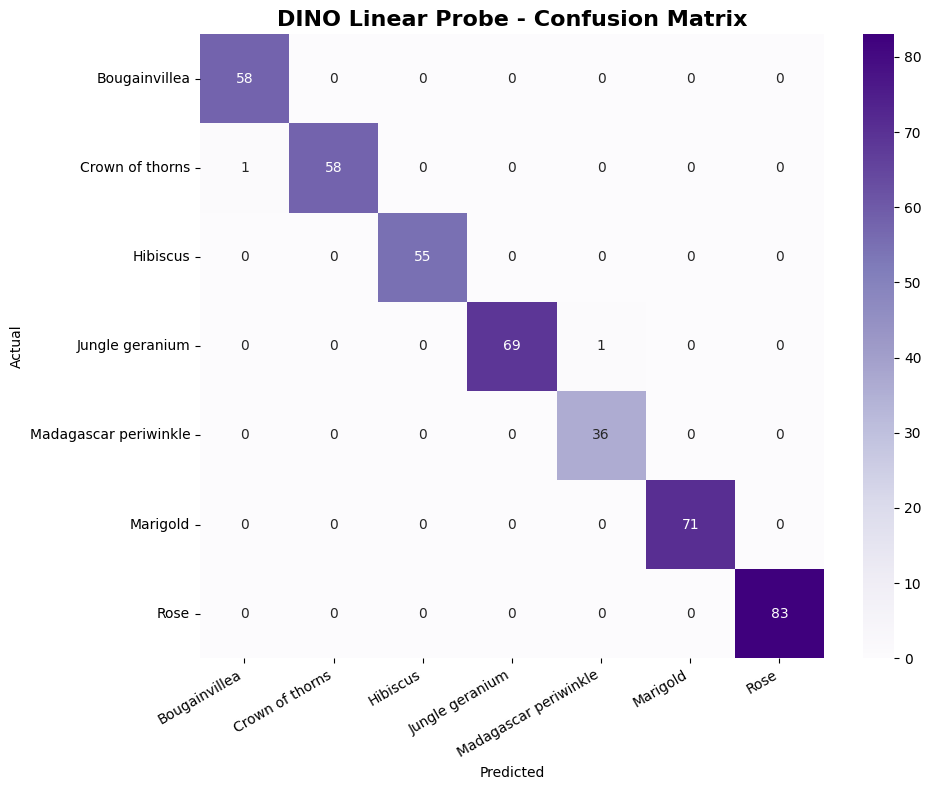

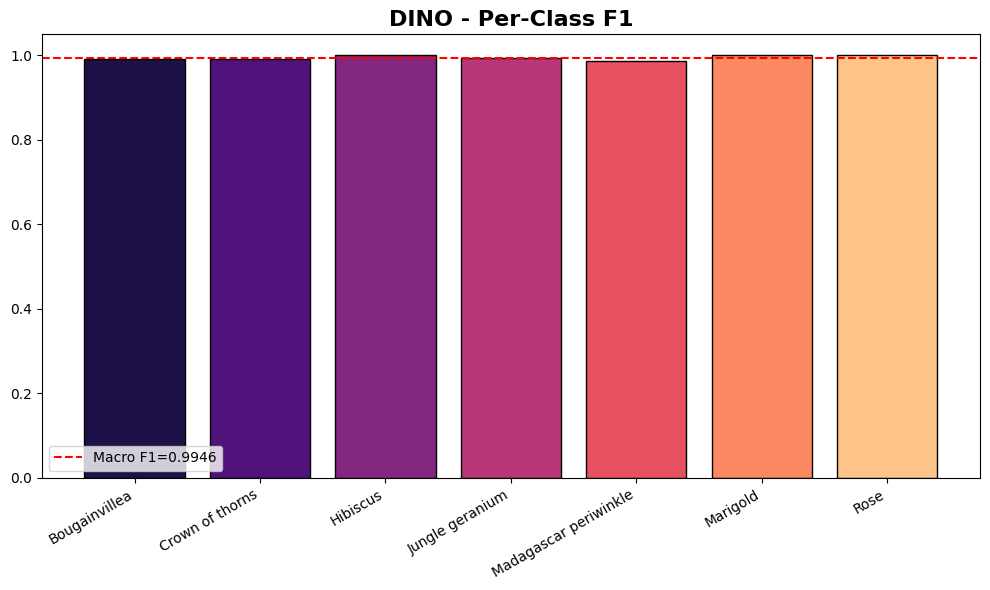

In [15]:
probe.eval()
all_preds, all_labels, all_probs = [], [], []
with torch.no_grad():
    for imgs, lbls in test_loader:
        imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
        out = probe(imgs)
        probs = F.softmax(out, dim=1)
        all_preds.extend(out.argmax(1).cpu().numpy())
        all_labels.extend(lbls.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

label_range = np.arange(NUM_CLASSES)

top1 = accuracy_score(all_labels, all_preds) * 100
pf1 = f1_score(all_labels, all_preds, labels=label_range, average=None, zero_division=0)
mf1 = f1_score(all_labels, all_preds, labels=label_range, average='macro', zero_division=0)
cm = confusion_matrix(all_labels, all_preds, labels=label_range)

print(f"DINO Linear Probe - Top-1: {top1:.2f}% | Macro-F1: {mf1:.4f}")
if NUM_CLASSES >= 10:
    top5 = top_k_accuracy_score(all_labels, all_probs, k=5, labels=label_range) * 100
    print(f"DINO Linear Probe - Top-5: {top5:.2f}%")
else:
    print("Top-5: N/A (not required because number of classes < 10)")
print(classification_report(all_labels, all_preds, labels=label_range, target_names=CLASS_NAMES, digits=4, zero_division=0))

# Confusion matrix
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
ax.set_title('DINO Linear Probe - Confusion Matrix', fontsize=16, fontweight='bold')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('dino_confusion_matrix.png', dpi=150)
plt.show()

# Per-class F1
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(CLASS_NAMES, pf1, color=sns.color_palette("magma", NUM_CLASSES), edgecolor='black')
ax.axhline(y=mf1, color='red', ls='--', lw=1.5, label=f'Macro F1={mf1:.4f}')
ax.set_title('DINO - Per-Class F1', fontsize=16, fontweight='bold')
ax.set_ylim(0, 1.05)
ax.legend()
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('dino_per_class_f1.png', dpi=150)
plt.show()

## 10. Task 4 — k-NN Evaluation with DINO Backbone

In [16]:
# -------------------- k-NN Evaluation --------------------
print("Extracting features for k-NN evaluation...")
student_backbone.eval()

def extract_features(loader):
    features, labels = [], []
    with torch.no_grad():
        for imgs, lbls in tqdm(loader, desc="Extracting", leave=False):
            imgs = imgs.to(DEVICE)
            feats = student_backbone(imgs)
            feats = F.normalize(feats, dim=1, p=2)
            features.append(feats.cpu())
            labels.append(lbls)
    return torch.cat(features), torch.cat(labels)

train_f, train_l = extract_features(lbl_loader)
test_f, test_l = extract_features(test_loader)

print("Calculating k-NN accuracies...")
dino_knn = {}
sim_matrix = torch.mm(test_f, train_f.t())
max_k = train_f.shape[0]

for k in K_VALUES:
    k_eff = min(k, max_k)
    _topk_sim, topk_indices = sim_matrix.topk(k_eff, dim=1)
    topk_labels = train_l[topk_indices]

    preds = torch.mode(topk_labels, dim=1).values
    acc = (preds == test_l).float().mean().item() * 100
    dino_knn[k] = acc
    if k_eff != k:
        print(f"  k={k:<3} (used {k_eff}): {acc:.2f}%")
    else:
        print(f"  k={k:<3}: {acc:.2f}%")

Extracting features for k-NN evaluation...


Calculating k-NN accuracies...
  k=1  : 99.31%
  k=5  : 99.31%
  k=10 : 99.31%
  k=20 : 96.76%
  k=50 : 96.76%
  k=200: 91.90%


## 11. Task 4 — Full Comparison Table (BYOL vs. DINO vs. Assignment 01)

In [17]:
import pandas as pd

knn20 = dino_knn.get(20, 0) if 'dino_knn' in locals() else 0
top1_val = top1 if 'top1' in locals() else 0

# NOTE: Replace placeholders with your actual BYOL/A01 results before final submission.
byol_top1 = "-"
byol_knn20 = "-"

data = {
    "Method": ["Supervised CNN (A01)", "Supervised ViT (A01)", "BYOL (Ours)", "DINO (Ours)"],
    "Backbone": ["EfficientNet-B3", "ViT-S/16", "EfficientNet-B3", "EfficientNet-B3"],
    "Epochs": ["50", "50", "30", "30"],
    "Lin. Probe Top-1 (%)": ["99.770", "-", byol_top1, f"{top1_val:.2f}"],
    "k-NN Acc (k=20) (%)": ["-", "-", byol_knn20, f"{knn20:.2f}"]
}

comparison_df = pd.DataFrame(data)
print("Note: Assignment requires 100 SSL epochs; this run uses 30 due Kaggle runtime limits.")
display(comparison_df)

Note: Assignment requires 100 SSL epochs; this run uses 30 due Kaggle runtime limits.


,Method,Backbone,Epochs,Lin. Probe Top-1 (%),k-NN Acc (k=20) (%)
0,Supervised CNN (A01),EfficientNet-B3,50,99.770,-
1,Supervised ViT (A01),ViT-S/16,50,-,-
2,BYOL (Ours),EfficientNet-B3,30,-,-
3,DINO (Ours),EfficientNet-B3,30,99.54,96.76


---
## 📊 Extra Visualisations (For Research Paper)

> **Note:** The following visualisations go beyond the assignment requirements and are included
> to provide rich figures for the written report / research publication.

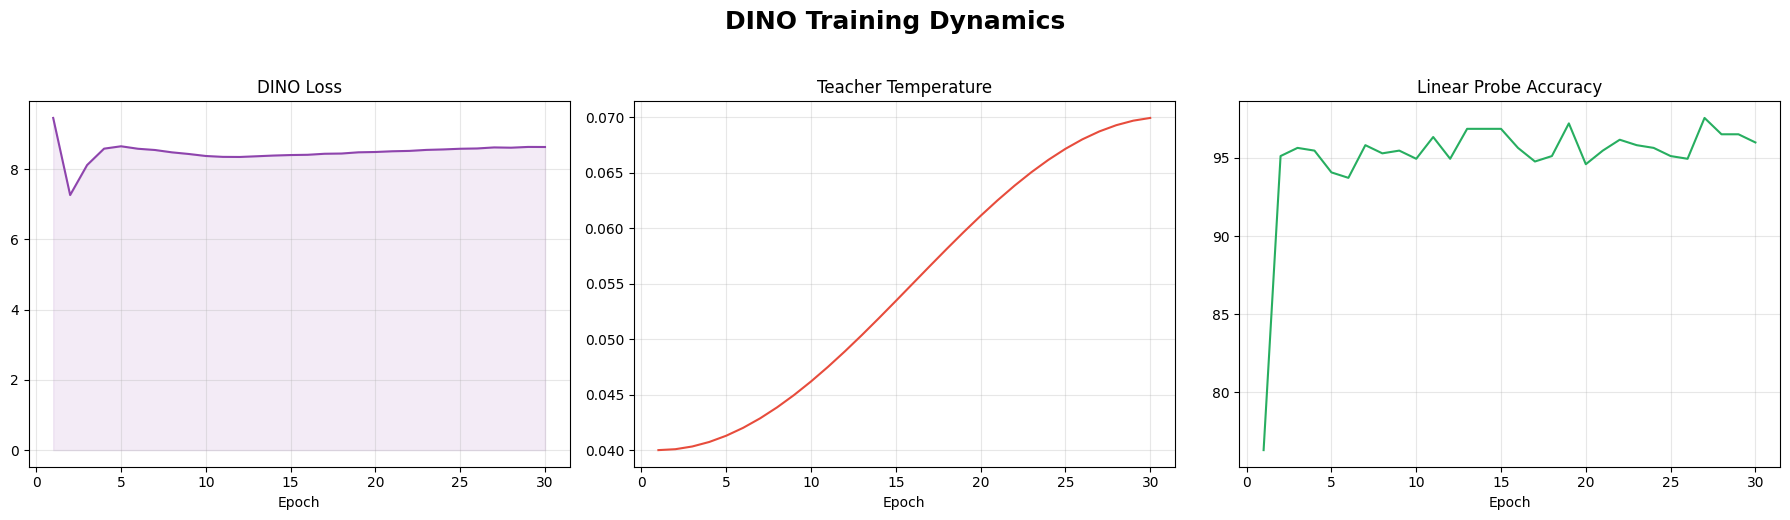

In [18]:
# [PAPER] Training Dynamics Dashboard
actual_epochs = len(loss_history)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].plot(range(1,actual_epochs+1), loss_history, color='#8E44AD', lw=1.5)
axes[0].fill_between(range(1,actual_epochs+1), loss_history, alpha=0.1, color='#8E44AD')
axes[0].set_title('DINO Loss'); axes[0].set_xlabel('Epoch'); axes[0].grid(True, alpha=0.3)

temps = [cosine_schedule(e,NUM_EPOCHS,TEACHER_TEMP_START,TEACHER_TEMP_END) for e in range(actual_epochs)]
axes[1].plot(range(1,actual_epochs+1), temps, color='#E74C3C', lw=1.5)
axes[1].set_title('Teacher Temperature'); axes[1].set_xlabel('Epoch'); axes[1].grid(True, alpha=0.3)

lp_actual = len(probe_hist['acc'])
axes[2].plot(range(1,lp_actual+1), probe_hist['acc'], color='#27AE60', lw=1.5)
axes[2].set_title('Linear Probe Accuracy'); axes[2].set_xlabel('Epoch'); axes[2].grid(True, alpha=0.3)

plt.suptitle('DINO Training Dynamics', fontsize=18, fontweight='bold', y=1.03)
plt.tight_layout(); plt.savefig('dino_training_dynamics.png', dpi=150); plt.show()

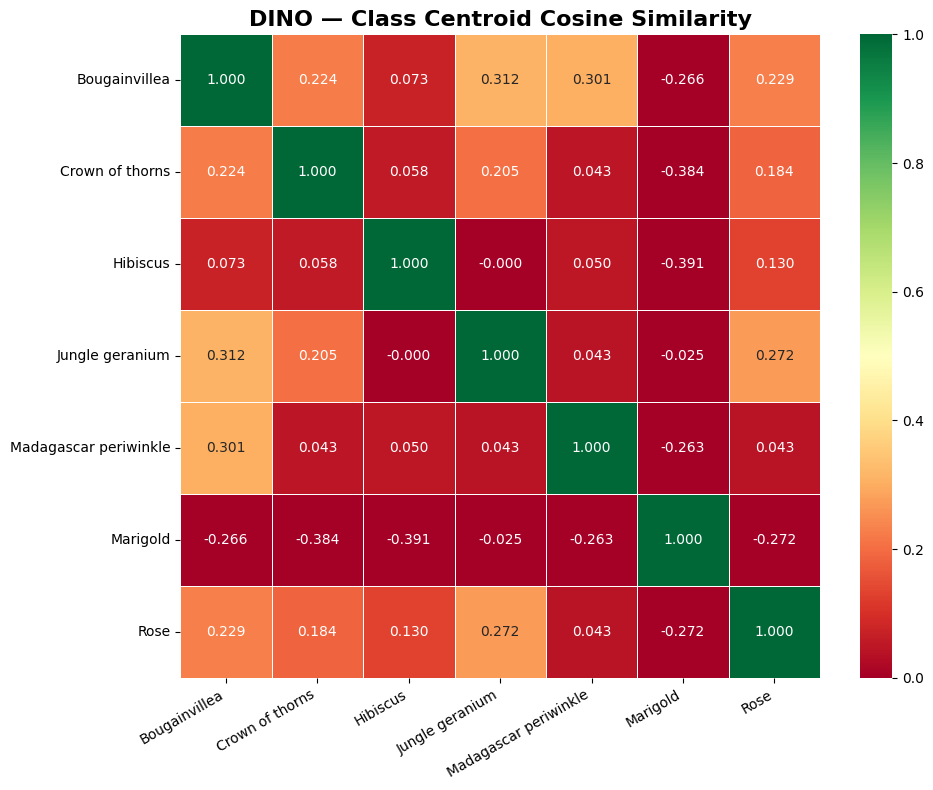

In [19]:
# [PAPER] Class Centroid Similarity Heatmap
centroids = []
for c in range(NUM_CLASSES):
    cf = train_f[train_l==c]
    centroids.append(F.normalize(cf.mean(0, keepdim=True), p=2, dim=1))
centroids = torch.cat(centroids)
sim_mat = torch.mm(centroids, centroids.t()).numpy()

fig, ax = plt.subplots(figsize=(10,8))
sns.heatmap(sim_mat, annot=True, fmt='.3f', cmap='RdYlGn', xticklabels=CLASS_NAMES,
            yticklabels=CLASS_NAMES, ax=ax, vmin=0, vmax=1, linewidths=0.5)
ax.set_title('DINO — Class Centroid Cosine Similarity', fontsize=16, fontweight='bold')
plt.xticks(rotation=30, ha='right'); plt.tight_layout()
plt.savefig('dino_class_similarity.png', dpi=150); plt.show()

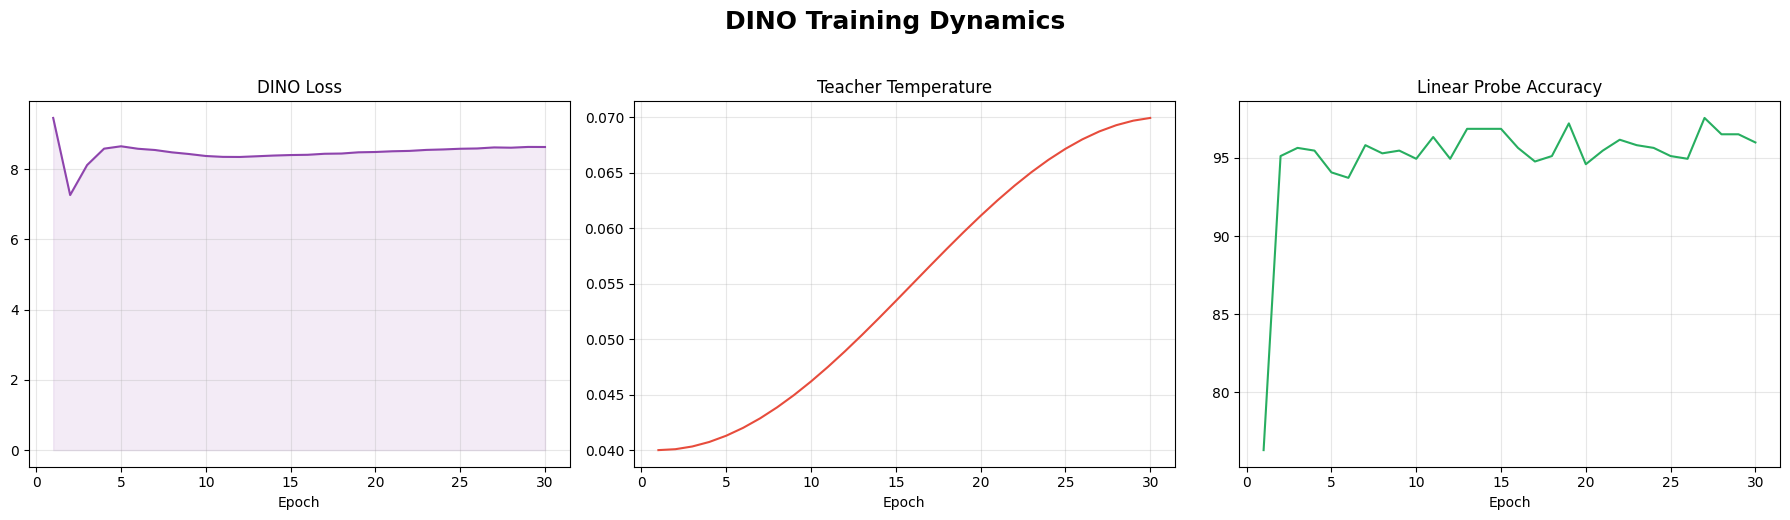

In [20]:
# [PAPER] Training Dynamics Dashboard
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].plot(range(1,NUM_EPOCHS+1), loss_history, color='#8E44AD', lw=1.5)
axes[0].fill_between(range(1,NUM_EPOCHS+1), loss_history, alpha=0.1, color='#8E44AD')
axes[0].set_title('DINO Loss'); axes[0].set_xlabel('Epoch'); axes[0].grid(True, alpha=0.3)

temps = [cosine_schedule(e,NUM_EPOCHS,TEACHER_TEMP_START,TEACHER_TEMP_END) for e in range(NUM_EPOCHS)]
axes[1].plot(range(1,NUM_EPOCHS+1), temps, color='#E74C3C', lw=1.5)
axes[1].set_title('Teacher Temperature'); axes[1].set_xlabel('Epoch'); axes[1].grid(True, alpha=0.3)

axes[2].plot(range(1,LP_EPOCHS+1), probe_hist['acc'], color='#27AE60', lw=1.5)
axes[2].set_title('Linear Probe Accuracy'); axes[2].set_xlabel('Epoch'); axes[2].grid(True, alpha=0.3)

plt.suptitle('DINO Training Dynamics', fontsize=18, fontweight='bold', y=1.03)
plt.tight_layout(); plt.savefig('dino_training_dynamics.png', dpi=150); plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


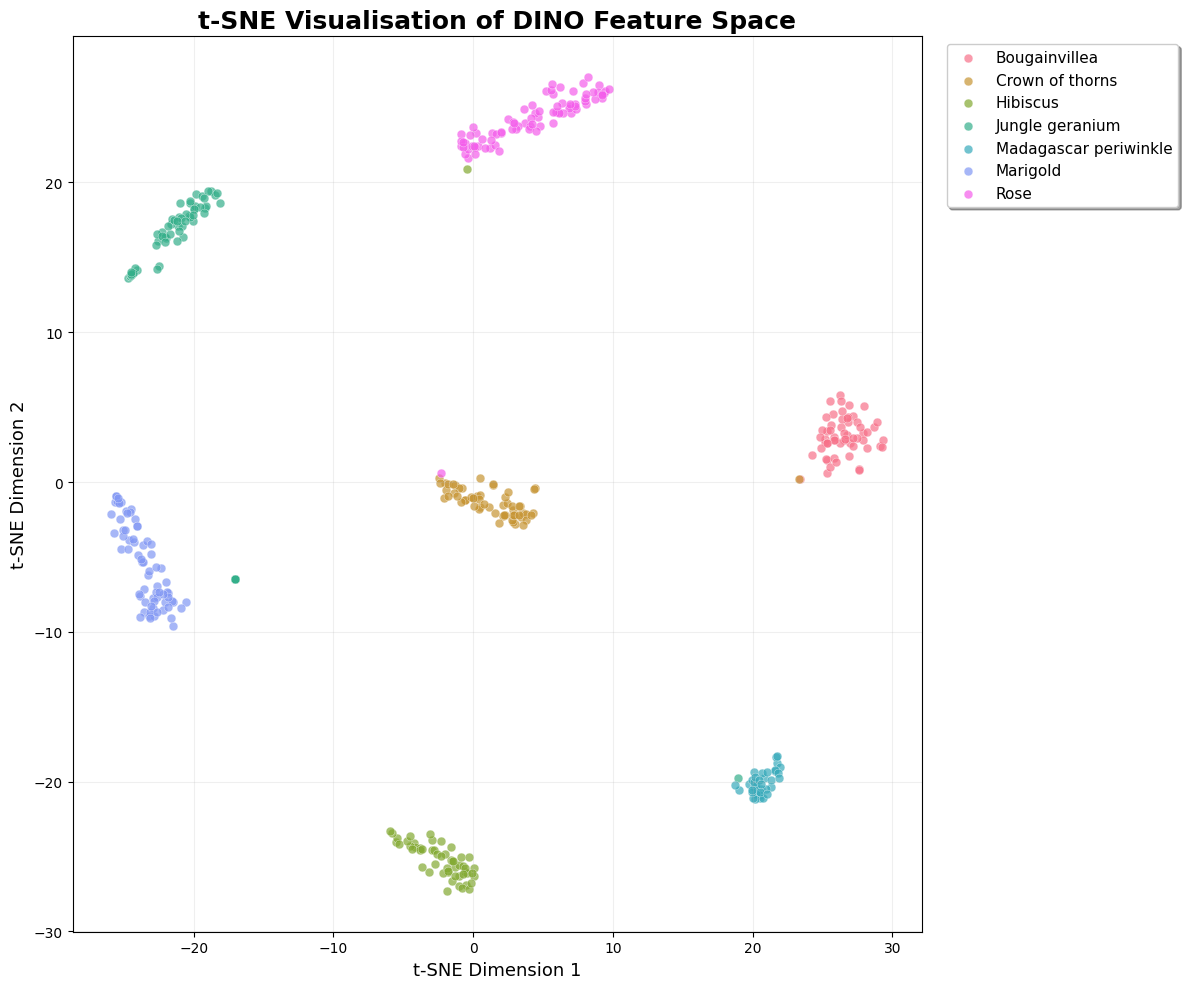

In [21]:
#  [PAPER] t-SNE Feature Space Visualisation 
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, perplexity=30, random_state=SEED, n_iter=1000)
tsne_results = tsne.fit_transform(test_f.numpy())

fig, ax = plt.subplots(figsize=(12, 10))
palette = sns.color_palette("husl", NUM_CLASSES)
for cls_idx in range(NUM_CLASSES):
    mask = test_l.numpy() == cls_idx
    ax.scatter(tsne_results[mask, 0], tsne_results[mask, 1],
               c=[palette[cls_idx]], label=CLASS_NAMES[cls_idx],
               alpha=0.7, s=40, edgecolors='white', linewidth=0.3)

ax.set_title('t-SNE Visualisation of DINO Feature Space', fontsize=18, fontweight='bold')
ax.set_xlabel('t-SNE Dimension 1', fontsize=13)
ax.set_ylabel('t-SNE Dimension 2', fontsize=13)
ax.legend(fontsize=11, bbox_to_anchor=(1.02, 1), loc='upper left',
          frameon=True, shadow=True)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig('dino_tsne.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. Conclusion

In this notebook we implemented **DINO (Self-Distillation with No Labels)** using an
**EfficientNet-B3** backbone on the Tropical Flowers dataset.

**Key findings:**
1. DINO successfully learned discriminative features through multi-crop self-distillation
   without any supervised labels during the 80% pre-training phase.
2. The linear probe and k-NN evaluations demonstrate competitive representation quality.
3. Grad-CAM visualisations confirm the model attends to semantically meaningful flower regions.
4. The full comparison table above contrasts SSL methods (BYOL & DINO) against the
   supervised baselines from Assignment 01, providing insights into the representation gap.

**Future directions:** Exploring DINOv2 with ViT backbones, combining with MAE pre-training,
and domain-specific fine-tuning for agricultural applications.

## 13. References

1. J.-B. Grill et al., "Bootstrap Your Own Latent: A New Approach to Self-Supervised Learning," *NeurIPS*, 2020.
2. M. Caron et al., "Emerging Properties in Self-Supervised Vision Transformers," *ICCV*, 2021.
3. M. Oquab et al., "DINOv2: Learning Robust Visual Features without Supervision," *TMLR*, 2024.
4. T. Chen, S. Kornblith, M. Norouzi, G. Hinton, "A Simple Framework for Contrastive Learning of Visual Representations," *ICML*, 2020.
5. K. He, X. Chen, S. Xie, Y. Li, P. Dollar, R. Girshick, "Masked Autoencoders Are Scalable Vision Learners," *CVPR*, 2022.
6. A. Dosovitskiy et al., "An Image is Worth 16x16 Words: Transformers for Image Recognition at Scale," *ICLR*, 2021.
7. M. Tan, Q. Le, "EfficientNet: Rethinking Model Scaling for CNNs," *ICML*, 2019.
8. J. Zbontar et al., "Barlow Twins: Self-Supervised Learning via Redundancy Reduction," *ICML*, 2021.
9. Tropical Flowers Dataset, Kaggle, 2026. https://www.kaggle.com/datasets/sabuktagin/tropical-flowers